In [129]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe
from scipy import stats
import cmocean.cm as cmo
import xrscipy.signal as dsp
from scipy.signal import butter
from meridional_streamfunction import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [206]:
ds_sigma2 = xr.open_mfdataset("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp25_budgets_sigma2_1750-1754.zarr", engine = "zarr")

In [238]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
tracers_ds = xr.open_dataset(savedir + "IndoPac_Tracer_Avg_on_sigma2.zarr", engine = "zarr")
tracers_ds.coords["sigma2_i"] = ds_sigma2.sigma2_i.values

dz = tracers_ds["depth"].diff("sigma2_l")
dz = dz.pad(sigma2_l=(1, 0), mode="edge")
dz.coords["sigma2_l"] = ds_sigma2.sigma2_l.values

#filtering
tracers_ds = tracers_ds.reset_coords("depth").where(dz > 0.0)
tracers_ds = tracers_ds.sel(sigma2_l = slice(35, 40))
tracers_ds["depth"] = tracers_ds["depth"].where(tracers_ds["depth"] > 100.0)
tracers_ds = tracers_ds.where(~np.isnan(tracers_ds["depth"]))

In [239]:
from xgcm import Grid

grid = xgcm.Grid(
    tracers_ds, coords={"Z": {"left": "sigma2_i", "center":"sigma2_l"}}, autoparse_metadata=False, 
    periodic = False
)
depth_target = np.linspace(1000, 5000, 100)

sigma_to_depth_transform = lambda ds_var, depth_ds: grid.transform(ds_var, "Z", depth_target, target_data=depth_ds, method="linear")

tracers_ds_mean = tracers_ds.mean("year")
tracers_ds_mean.coords["depth"] = tracers_ds["depth"].mean("year", skipna = True)
tracers_ds_depth = sigma_to_depth_transform(tracers_ds_mean["thetao"], tracers_ds_mean["depth"]).to_dataset()

psids_transformed["thetao"] = sigma_to_depth_transform(psids["sigma2_i"].broadcast_like(psids["psi"]), psids["depth"])

In [ ]:
tracers_ds_depth.thetao.isel(expt = 0).plot()

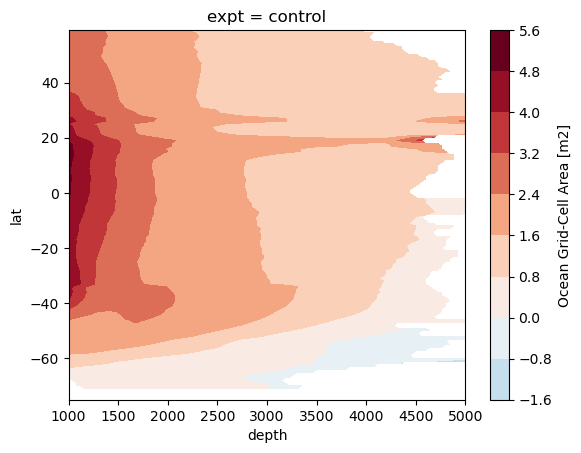

In [242]:
tracers_ds_depth.thetao.isel(expt = 0).plot.contourf()

Text(0.5, 0.98, 'Meridional Isopycnal Indo-Pacific Overturning Streamfunction')

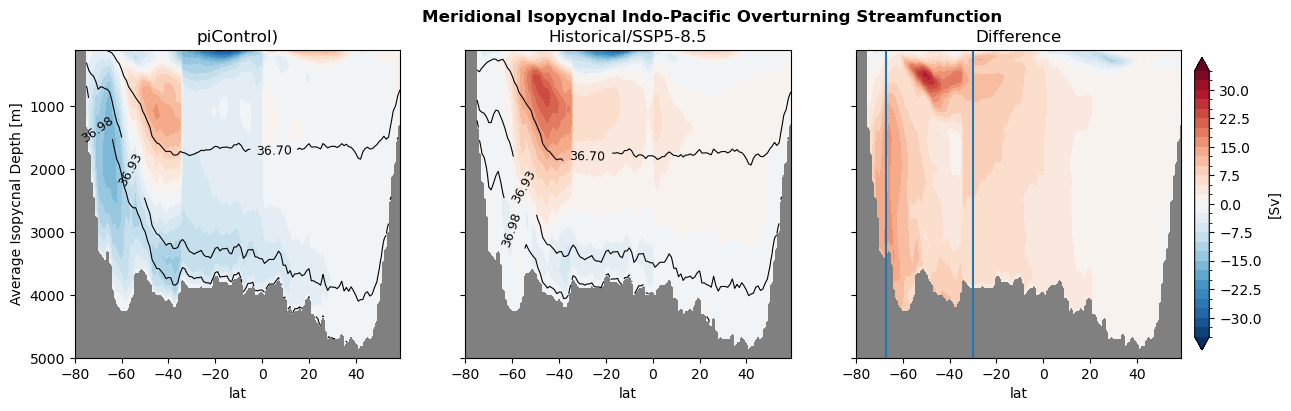

In [53]:

# depth_target = np.arange(0, 5501, 50)

sigma_to_depth_transform = lambda ds_var, depth_ds: grid.transform(ds_var, "Z", depth_target, target_data=depth_ds)
# create one figure with two subplots
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)

# first subplot: control
ax = axes[0]
exp = "control"
psids = psis_ds.sel(exp=exp).fillna(0.0).mean("time")
psids_transformed = sigma_to_depth_transform(psids["psi"].fillna(0.0), psids["depth"]).to_dataset()
psids_transformed["sigma2"] = sigma_to_depth_transform(psids["sigma2_i"].broadcast_like(psids["psi"]), psids["depth"])
plot_psi(fig, ax, psids_transformed["psi"], sigma = psids_transformed["sigma2"])
ax.set_title(f"piControl)")
ax.set_ylabel("Average Isopycnal Depth [m]")

# # # first subplot: forced
ax = axes[1]
exp = "forced"
psids = psis_ds.sel(exp=exp).fillna(0.0).sel(time = slice(2090, None)).mean("time")
psids_transformed = sigma_to_depth_transform(psids["psi"].fillna(0.0), psids["depth"]).to_dataset()
psids_transformed["sigma2"] = sigma_to_depth_transform(psids["sigma2_i"].broadcast_like(psids["psi"]), psids["depth"])
plot_psi(fig, ax, psids_transformed["psi"], sigma = psids_transformed["sigma2"])
ax.set_title(f"Historical/SSP5-8.5")

# # first subplot: forced
ax = axes[2]
psids_forced = psis_ds.sel(exp="forced").fillna(0.0).sel(time = slice(2090, None)).mean("time")
psids_control_mean = psis_ds.sel(exp="control").mean("time")
psids_control_std = psis_ds.sel(exp="control").std("time")

psids = psids_forced - psids_control_mean
psids_transformed = sigma_to_depth_transform(psids["psi"].fillna(0.0), psids_forced["depth"]).to_dataset()
# psi_new = psids["psi"].fillna(0.0)
plot_psi(fig, ax, psids_transformed["psi"], add_colorbar = True, cbar_ax = axes)
ax.set_title(f"Difference")
ax.axvline(-30)
ax.axvline(-67)
fig.suptitle("Meridional Isopycnal Indo-Pacific Overturning Streamfunction", fontweight = "bold")


In [54]:
def get_trend(da, time_dim = "year"): 
        # 1. Fit a first-degree polynomial (linear trend) along the 'time' dimension
    p = da.polyfit(dim=f"{time_dim}", deg=1, skipna=False)
    
    # 2. Evaluate the linear trend as a time series
    fit = xr.polyval(da[f"{time_dim}"], p.polyfit_coefficients)
    return fit

In [84]:
def get_deep_psi_minimums(psis_ds, target_lat=-70, depth_thresh=1000):
    # 1. Grab the nearest latitude slice
    psi_at_lat = psis_ds.sel(lat=target_lat, method="nearest")
    
    # 2. Mask the streamfunction array to only include deep water
    deep_psi = psi_at_lat["psi"].where(psi_at_lat["depth"] > depth_thresh)
    
    # 3. Calculate the minimum value along the density coordinate
    min_psi = deep_psi.min(dim="sigma2_i")

    # 4. Find the specific density (sigma2_i) coordinate where that minimum occurs
    # (idxmin replaces the need for argmin + isel)
    sigmamin_psi = deep_psi.idxmin(dim="sigma2_i", skipna = True, fill_value = np.nan)

    min_depth = psi_at_lat["depth"].sel(sigma2_i = sigmamin_psi)

    
    return min_psi, sigmamin_psi, min_depth

In [222]:
from statsmodels.distributions.empirical_distribution import ECDF

def calc_ecdf_for_lat(control_pool, forced_timeseries):
    # control_pool is 1850-1950, forced_timeseries is 2000-2100
    # Both are received as raw 1D numpy arrays
    clean_control = control_pool[~np.isnan(control_pool)]
    # if len(clean_control) == 0:
    #     return np.full_like(forced_timeseries, np.nan)
    
    ecdf = ECDF(clean_control)
    return 1 - ecdf(forced_timeseries) #looking at the right tail of the distrinbution

Text(0.5, 0.98, 'Maximum SMOC Transport below 1000 meters')

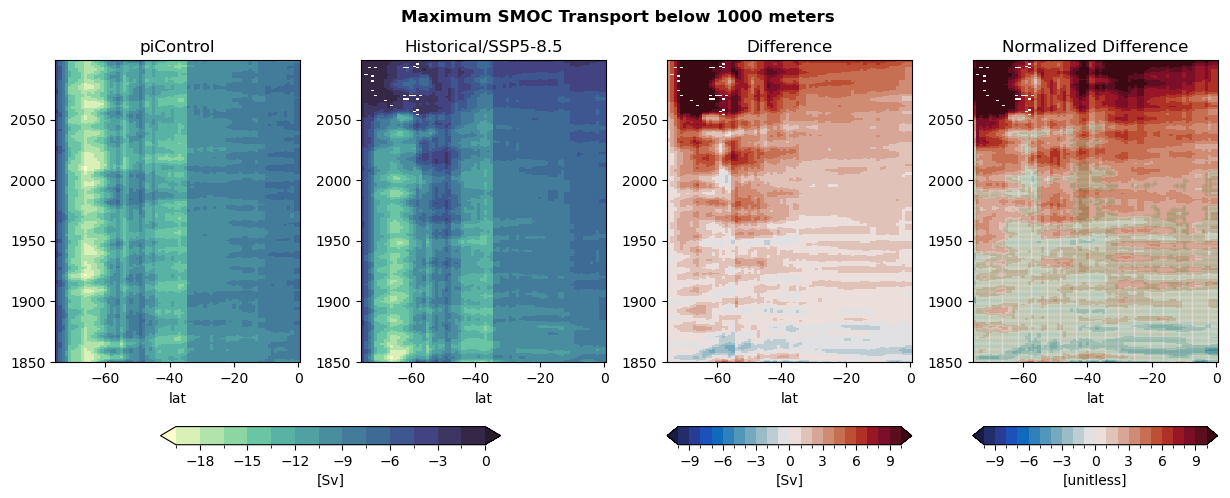

In [225]:
# low-pass filter setup
sos = butter(8, 1 / 10, btype="low", fs=1, output="sos")

# basic settings
depth_thresh = 750
alpha = 0.01

levels = -np.arange(0, 20 + 0.1, 1.5)[::-1]
anomaly_levels = np.arange(-10, 10 + 0.1, 1.0)
normalized_anomaly_levels = np.arange(-10, 10 + 0.1, 1.0)

# isolate deep negative overturning
deep_psi = psis_yearly_ds["psi"].where(psis_yearly_ds["depth"] > depth_thresh)
deep_psi = deep_psi.where(deep_psi < 0.0)

# take minimum over density classes
min_psi_unfiltered = deep_psi.min(dim="sigma2_i").sel(lat=slice(None, 0))
min_psi_unfilt_trend = get_trend(min_psi_unfiltered.interpolate_na("year"))

# filter only the detrended variability, then add trend back
min_psi = dsp.sosfiltfilt(sos, min_psi_unfiltered.interpolate_na("year") - min_psi_unfilt_trend, dim="year")
min_psi = min_psi.where(min_psi_unfiltered.notnull())
min_psi = min_psi + min_psi_unfilt_trend
min_psi = min_psi.where(min_psi < 0.0)

# split into control and forced experiments
baseline = min_psi.sel(exp="control")
forced = min_psi.sel(exp="forced")

# define control reference statistics
base = baseline.sel(year=slice(1850, 1950))
baseline_mean = base.mean("year")
baseline_std = base.std("year", ddof=1)

# compute anomalies
anomaly = forced - baseline_mean
normalized_anomaly = anomaly / baseline_std

# empirical significance test
p_values = xr.apply_ufunc(calc_ecdf_for_lat, baseline, forced,
    input_core_dims=[["year"], ["year"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="allowed")

mask = p_values > alpha

# significance marker coordinates
lat_2d, year_2d = xr.broadcast(mask["lat"], mask["year"])
lat_pts = lat_2d.where(mask).values.ravel()
year_pts = year_2d.where(mask).values.ravel()

# figure with dedicated colorbar row
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 0.06], hspace=0.4, wspace=0.25)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
ax3 = fig.add_subplot(gs[0, 3], sharey=ax0)

gs_cb01 = gs[1, 0:2].subgridspec(1, 3, width_ratios=[0.15, 0.7, 0.15])
cax01 = fig.add_subplot(gs_cb01[0, 1])
cax2 = fig.add_subplot(gs[1, 2])
cax3 = fig.add_subplot(gs[1, 3])

m0 = baseline.plot(ax=ax0, x="lat", y="year", add_colorbar=False, levels=levels, extend="both", cmap=cmo.deep)
m1 = forced.plot(ax=ax1, x="lat", y="year", add_colorbar=False, levels=levels, extend="both", cmap=cmo.deep)
m2 = anomaly.plot(ax=ax2, x="lat", y="year", add_colorbar=False, levels=anomaly_levels, extend="both", cmap=cmo.balance)
m3 = normalized_anomaly.plot(ax=ax3, x="lat", y="year", add_colorbar=False, levels=normalized_anomaly_levels, extend="both", cmap=cmo.balance)

fig.colorbar(m1, cax=cax01, orientation="horizontal", label="[Sv]")
fig.colorbar(m2, cax=cax2, orientation="horizontal", label="[Sv]")
fig.colorbar(m3, cax=cax3, orientation="horizontal", label="[unitless]")

good = np.isfinite(lat_pts) & np.isfinite(year_pts)
ax3.scatter(lat_pts[good], year_pts[good], s=3, c="green", marker="o", alpha=0.04)

ax0.set_title("piControl")
ax1.set_title("Historical/SSP5-8.5")
ax2.set_title("Difference")
ax3.set_title("Normalized Difference")

[a.set_ylabel("") for a in [ax0, ax1, ax2, ax3]]

fig.suptitle("Maximum SMOC Transport below 1000 meters", fontweight="bold")

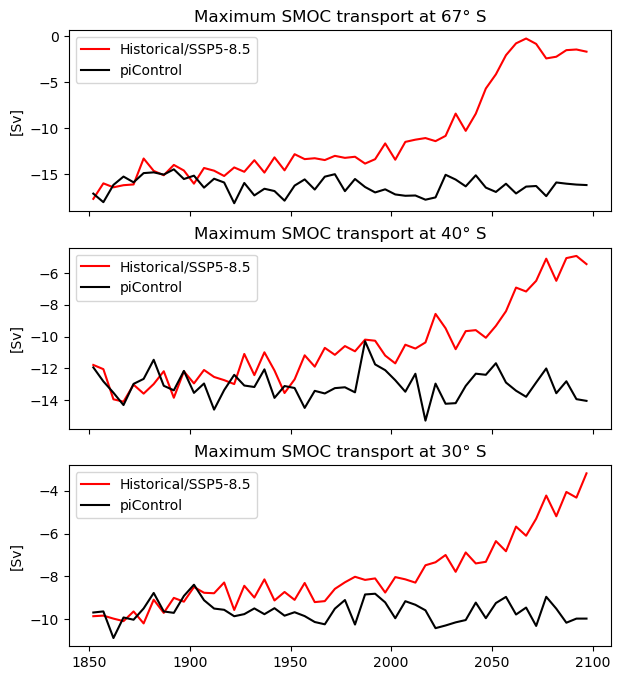

In [87]:
fig, ax = plt.subplots(3, 1, figsize = (7, 8), sharex = True)

expt_label = {"forced":"Historical/SSP5-8.5", "control":"piControl"}
expt_color = {"forced":"r", "control":"k"}

for (i, lat) in enumerate([-67, -40, -30]):
    min_psi, sigmamin_psi, min_depth = get_deep_psi_minimums(psis_ds, target_lat=lat)
    for expt in ["forced", "control"]:
        min_psi.sel(exp = expt).plot(ax = ax[i], label = expt_label[expt], color = expt_color[expt])
    ax[i].set_title(f"Maximum SMOC transport at {-lat}° S")

[a.set_xlabel("") for a in ax]
[a.set_ylabel("[Sv]") for a in ax]
[a.legend() for a in ax]

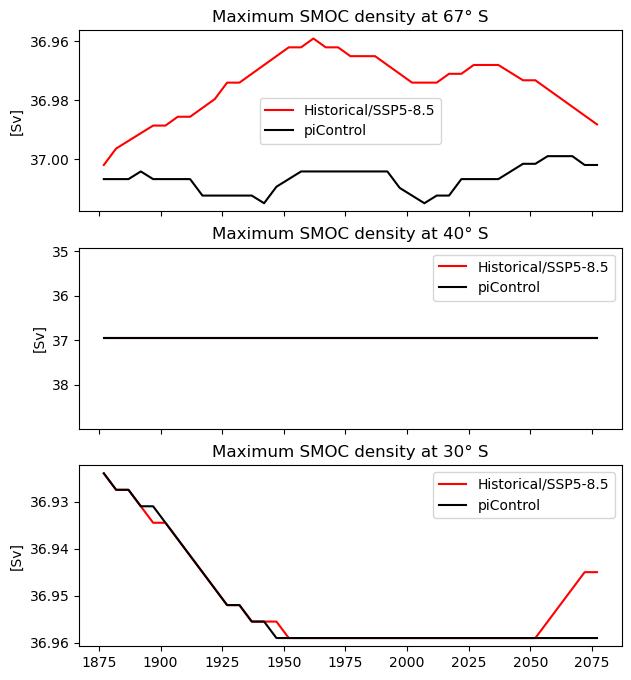

In [94]:
fig, ax = plt.subplots(3, 1, figsize = (7, 8), sharex = True)

for (i, lat) in enumerate([-67, -40, -30]):
    min_psi, sigmamin_psi, min_depth = get_deep_psi_minimums(psis_ds, target_lat=lat)
    for expt in ["forced", "control"]:
        tmp = sigmamin_psi.rolling(time = 10,center = True).mean()
        tmp.sel(exp = expt).plot(ax = ax[i], label = expt_label[expt], color = expt_color[expt])
    ax[i].set_title(f"Maximum SMOC density at {-lat}° S")

[a.invert_yaxis() for a in ax]

[a.set_xlabel("") for a in ax]
[a.set_ylabel("[Sv]") for a in ax]
[a.legend() for a in ax]

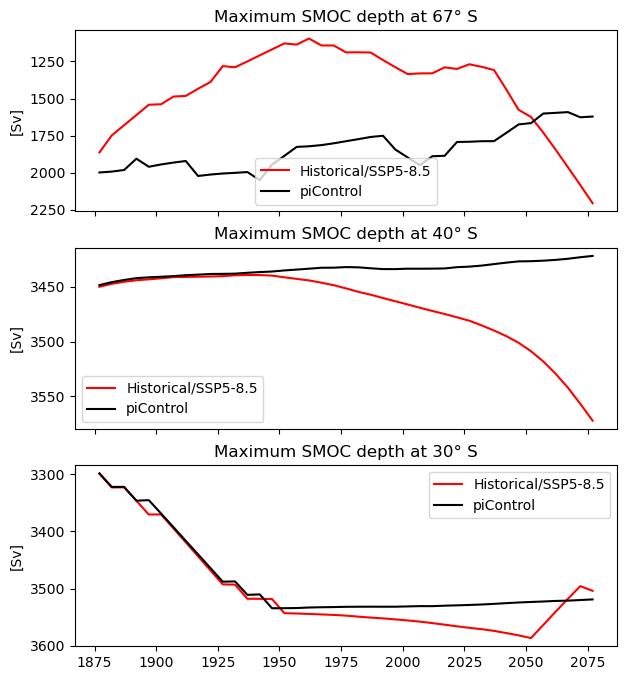

In [89]:
fig, ax = plt.subplots(3, 1, figsize = (7, 8), sharex = True)

for (i, lat) in enumerate([-67, -40, -30]):
    min_psi, sigmamin_psi, min_depth = get_deep_psi_minimums(psis_ds, target_lat=lat)
    for expt in ["forced", "control"]:
        min_depth.rolling(time = 10,center = True).mean().sel(exp = expt).plot(ax = ax[i], label = expt_label[expt], color = expt_color[expt])
    ax[i].set_title(f"Maximum SMOC depth at {-lat}° S")

[a.invert_yaxis() for a in ax]
[a.set_xlabel("") for a in ax]
[a.set_ylabel("[Sv]") for a in ax]
[a.legend() for a in ax]